<a href="https://colab.research.google.com/github/ipcanal/Java/blob/master/Previs%C3%A3o_demanda_energia_el%C3%A9trica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Seção 1: Configurações

In [52]:

#Instalando Kagglehub
!pip install -q kagglehub

## Seção 2: Importação de bibliotecas

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import kagglehub


O arquivo do Kaggle (https://www.kaggle.com/datasets/robikscube/hourly-energy-consumption) com os dados de Consumo de Energia possuem diversas variações do dataset. O grupo escolheu a variação "PMJE", dados da região Leste dos estados Unidos, conforme proposto na atividade.

## Seção 3: Carregamento dos dados

In [54]:
caminho = kagglehub.dataset_download(
    "robikscube/hourly-energy-consumption",
    path="PJME_hourly.csv"
)

#leitura do dataset gravada na variável df
df = pd.read_csv(caminho)

#vislumbre nos primeiros dados do dataset
df.head()

Using Colab cache for faster access to the 'hourly-energy-consumption' dataset.


,Datetime,PJME_MW
0,2002-12-31 01:00:00,26498.0
1,2002-12-31 02:00:00,25147.0
2,2002-12-31 03:00:00,24574.0
3,2002-12-31 04:00:00,24393.0
4,2002-12-31 05:00:00,24860.0


In [55]:
#vislumbre nos últimos dados do dataset, visualizando o período 2002 a 2018
df.tail()

,Datetime,PJME_MW
145361,2018-01-01 20:00:00,44284.0
145362,2018-01-01 21:00:00,43751.0
145363,2018-01-01 22:00:00,42402.0
145364,2018-01-01 23:00:00,40164.0
145365,2018-01-02 00:00:00,38608.0


In [56]:
df.info()

#Intervalo de tempo coberto pelo dataset
print("\n\nData inicial:", df["Datetime"].min())
print("Data final:", df["Datetime"].max())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145366 entries, 0 to 145365
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   Datetime  145366 non-null  object 
 1   PJME_MW   145366 non-null  float64
dtypes: float64(1), object(1)
memory usage: 2.2+ MB


Data inicial: 2002-01-01 01:00:00
Data final: 2018-08-03 00:00:00


O dataset possui dados de consumo de energia entre as datas de 01/01/2002 a 03/08/2018. No total, são 145366 dados de consumo, cada um com 2 colunas, "Datetime" (Data e Hora) e "PMJE_MW" (Consumo em MegaWatts).


##Seção 4: Limpeza e preparação dos dados


##4.1: Análise do Dataset

In [57]:

#Análise do Dataset
print("Quantidade de registros:", len(df))

print("\nValores nulos:")
print(df.isnull().sum())

# Duplicação da linha inteira
print("\nDuplicados de linhas completas:")
print(df.duplicated().sum())

# Duplicação apenas do horário
print("\nDuplicados de Datetime:")
print(df["Datetime"].duplicated().sum())

# Mostra todas as linhas que possuem Datetime repetido
print("\nRegistros com Datetime duplicado:")
print(
    df[df["Datetime"].duplicated(keep=False)]
    .sort_values("Datetime")
)


Quantidade de registros: 145366

Valores nulos:
Datetime    0
PJME_MW     0
dtype: int64

Duplicados de linhas completas:
0

Duplicados de Datetime:
4

Registros com Datetime duplicado:
                   Datetime  PJME_MW
106584  2014-11-02 02:00:00  22935.0
106585  2014-11-02 02:00:00  23755.0
115368  2015-11-01 02:00:00  21567.0
115369  2015-11-01 02:00:00  21171.0
124008  2016-11-06 02:00:00  20795.0
124009  2016-11-06 02:00:00  21692.0
132816  2017-11-05 02:00:00  21236.0
132817  2017-11-05 02:00:00  20666.0


No dataset, existem 4 conjuntos Datetime duplicados devido ao fim do horário de verão nos estados unidos.

O horário de verão nos EUA termina no início do mês de novembro, às 02h (período quando as datas duplicadas ocorrem). O horário é atrasado em 1 hora e o horário das 02h ocorre duas vezes, portando a duplicação não é um erro do dataset, mas um registro real.

A solução será agrupar os registros com o mesmo horário e usar a média do consumo desses registros, para que não haja mais datas duplicadas.

##4.2: Correção dos registros duplicados

In [58]:
# Converte para datetime
df["Datetime"] = pd.to_datetime(df["Datetime"])

# Ordena cronologicamente
df = df.sort_values("Datetime")

# Junta timestamps duplicados calculando a média do consumo
df = (
    df.groupby("Datetime", as_index=False)["PJME_MW"]
      .mean()
)

# Reorganiza o índice
df = df.reset_index(drop=True)

#Checando as duplicações novamente, garantindo que foram corrigidas:
# Duplicação da linha inteira
print("\nDuplicados de linhas completas:")
print(df.duplicated().sum())

# Duplicação apenas do horário
print("\nDuplicados de Datetime:")
print(df["Datetime"].duplicated().sum())


Duplicados de linhas completas:
0

Duplicados de Datetime:
0


## 4.3: Verificação de horas ausentes na série completa





In [59]:

# Todas as horas que deveriam existir entre o primeiro e o último registro
horas_esperadas = pd.date_range(
    start=df["Datetime"].min(),
    end=df["Datetime"].max(),
    freq="h"
)

# Horas que deveriam existir, mas não estão no dataset
horas_ausentes = horas_esperadas.difference(df["Datetime"])

print("Horas esperadas no período:", len(horas_esperadas))
print("Registros no dataset:      ", len(df))
print("Horas ausentes:            ", len(horas_ausentes))

# Agrupa horas ausentes consecutivas em lacunas
# (uma nova lacuna começa quando a distância para a hora anterior é maior que 1 hora)
ausentes = pd.Series(horas_ausentes)
id_lacuna = (ausentes.diff() != pd.Timedelta(hours=1)).cumsum()

lacunas = (
    ausentes.groupby(id_lacuna)
            .agg(inicio="min", fim="max", horas="count")
            .reset_index(drop=True)
)

# Informações de apoio para identificar a causa de cada lacuna
lacunas["dia_semana"] = lacunas["inicio"].dt.dayofweek   # 6 = domingo
lacunas["mes"] = lacunas["inicio"].dt.month

print("\nLacunas encontradas:")
print(lacunas)

Horas esperadas no período: 145392
Registros no dataset:       145362
Horas ausentes:             30

Lacunas encontradas:
                inicio                 fim  horas  dia_semana  mes
0  2002-04-07 03:00:00 2002-04-07 03:00:00      1           6    4
1  2002-10-27 02:00:00 2002-10-27 02:00:00      1           6   10
2  2003-04-06 03:00:00 2003-04-06 03:00:00      1           6    4
3  2003-10-26 02:00:00 2003-10-26 02:00:00      1           6   10
4  2004-04-04 03:00:00 2004-04-04 03:00:00      1           6    4
5  2004-10-31 02:00:00 2004-10-31 02:00:00      1           6   10
6  2005-04-03 03:00:00 2005-04-03 03:00:00      1           6    4
7  2005-10-30 02:00:00 2005-10-30 02:00:00      1           6   10
8  2006-04-02 03:00:00 2006-04-02 03:00:00      1           6    4
9  2006-10-29 02:00:00 2006-10-29 02:00:00      1           6   10
10 2007-03-11 03:00:00 2007-03-11 03:00:00      1           6    3
11 2007-11-04 02:00:00 2007-11-04 02:00:00      1           6   11
12 200

##Verificação de horas ausentes
Durante o desenvolvimento do baseline (Seção 7), surgiu a suspeita de que o conjunto de teste continha horas ausentes. Esse problema é relevante porque a estratégia “amanhã será igual a hoje” pressupõe uma série temporal contínua, em que cada dia possui uma sequência horária consistente.


A verificação realizada inicialmente no conjunto de teste identificou 3 horas ausentes, associadas ao início do horário de verão nos Estados Unidos. Ao analisar a série completa, constatou-se que essas lacunas não estavam restritas ao teste (no dataset inteiro, 30 ausências no total). Por isso, sua identificação e tratamento foram movidos para esta etapa de limpeza.


Para manter a frequência horária contínua, os horários ausentes foram inseridos na série e seus valores de consumo foram estimados por interpolação (média) entre os registros vizinhos.

**Impactos das horas ausentes nas demais etapas:**
- Seção 7 (Baseline): o baseline utiliza as últimas 24 horas para representar o dia anterior. Se houver uma hora ausente, 24 posições consecutivas podem deixar de representar exatamente 24 horas, prejudicando a correspondência entre os mesmos horários de dias consecutivos.
- Seções 8 e 9 (Sequências): as janelas de entrada possuem 168 horas. Sem o tratamento das lacunas, 168 registros poderiam representar um intervalo superior a 168 horas, provocando desalinhamento temporal entre entrada e alvo.
- Seções 10 e 11 (GRU): a GRU aprende padrões a partir dessas sequências. Garantir intervalos horários regulares evita que o modelo aprenda relações temporais distorcidas. Além disso, valores ausentes (NaN) precisam ser tratados antes do treinamento.

  ***

##Coerência temporal:

Os timestamps duplicados associados ao fim do horário de verão e as horas ausentes relacionadas ao início do horário de verão possuem a mesma origem: a mudança do relógio. Ambos são tratados na etapa de preparação dos dados para transformar a série em uma sequência horária regular.



###Início do horario de verão: Relógio adiantado, pula-se o horário das 02h (1h59 -> 03h)

###Fim do horário de verão: Relógio atrasado, o horário das 2h acontece 2 vezes.

##4.4: Preenchimento das horas ausentes


In [60]:

# Coloca Datetime como índice para trabalhar com a série temporal
df = df.set_index("Datetime")

# Reindexa o dataset utilizando todas as horas que deveriam existir.
# As horas que não existiam passam a aparecer com PJME_MW = NaN.
df = df.reindex(horas_esperadas)

# Nomeia novamente o índice
df.index.name = "Datetime"

# Marca quais registros foram criados por causa das horas ausentes.
# True = registro que não existia originalmente.
df["interpolado"] = df["PJME_MW"].isna()

# Preenche apenas os valores de consumo ausentes, mantendo os originais.
# Para uma única hora ausente entre dois registros, o valor será a média entre o consumo anterior e o posterior.
df["PJME_MW"] = df["PJME_MW"].interpolate(method="linear")

# Volta Datetime a ser uma coluna normal
df = df.reset_index()

##4.5: Verificações após o preenchimento

In [61]:


print("\n--- Após o preenchimento das lacunas ---")

print("Registros no dataset:", len(df))

print(
    "Registros interpolados:",
    df["interpolado"].sum()
)

print(
    "Valores de consumo ainda ausentes:",
    df["PJME_MW"].isna().sum()
)

# Mostra somente os registros que foram criados e interpolados
print("\nRegistros preenchidos por interpolação:")
print(
    df[df["interpolado"]][
        ["Datetime", "PJME_MW", "interpolado"]
    ]
)

# Nova verificação de continuidade temporal
horas_esperadas_depois = pd.date_range(
    start=df["Datetime"].min(),
    end=df["Datetime"].max(),
    freq="h"
)

horas_ausentes_depois = horas_esperadas_depois.difference(
    df["Datetime"]
)

print(
    "\nHoras ausentes após o tratamento:",
    len(horas_ausentes_depois)
)
print("\nDados originais possuem 'interpolado' como False:")
df.head()


--- Após o preenchimento das lacunas ---
Registros no dataset: 145392
Registros interpolados: 30
Valores de consumo ainda ausentes: 0

Registros preenchidos por interpolação:
                  Datetime  PJME_MW  interpolado
2306   2002-04-07 03:00:00  24612.5         True
7177   2002-10-27 02:00:00  21714.0         True
11042  2003-04-06 03:00:00  23123.5         True
15913  2003-10-26 02:00:00  21822.0         True
19778  2004-04-04 03:00:00  23354.5         True
24817  2004-10-31 02:00:00  21806.0         True
28514  2005-04-03 03:00:00  23577.0         True
33553  2005-10-30 02:00:00  24462.5         True
37250  2006-04-02 03:00:00  21144.5         True
42289  2006-10-29 02:00:00  24342.0         True
45482  2007-03-11 03:00:00  24448.0         True
51193  2007-11-04 02:00:00  24265.0         True
54218  2008-03-09 03:00:00  28149.0         True
59929  2008-11-02 02:00:00  22687.5         True
62954  2009-03-08 03:00:00  21834.0         True
68665  2009-11-01 02:00:00  22088.5     

,Datetime,PJME_MW,interpolado
0,2002-01-01 01:00:00,30393.0,False
1,2002-01-01 02:00:00,29265.0,False
2,2002-01-01 03:00:00,28357.0,False
3,2002-01-01 04:00:00,27899.0,False
4,2002-01-01 05:00:00,28057.0,False


##4.6: Estatísticas do consumo energético

In [62]:
print("\nEstatísticas:")
print(df.describe())


Estatísticas:
                  Datetime        PJME_MW
count               145392  145392.000000
mean   2010-04-18 00:30:00   32078.927654
min    2002-01-01 01:00:00   14544.000000
25%    2006-02-23 12:45:00   27571.000000
50%    2010-04-18 00:30:00   31420.000000
75%    2014-06-10 12:15:00   35647.000000
max    2018-08-03 00:00:00   62009.000000
std                    NaN    6464.283311


Alguns dados importantes ->

Consumo Máximo: 62009.00 MW

Consumo Mínimo: 14544.00 MW

Consumo Médio: 32080.50 MW


##Seção 5: Análise exploratória


##5.1: Consumo médio mensal entre 2002 a 2018

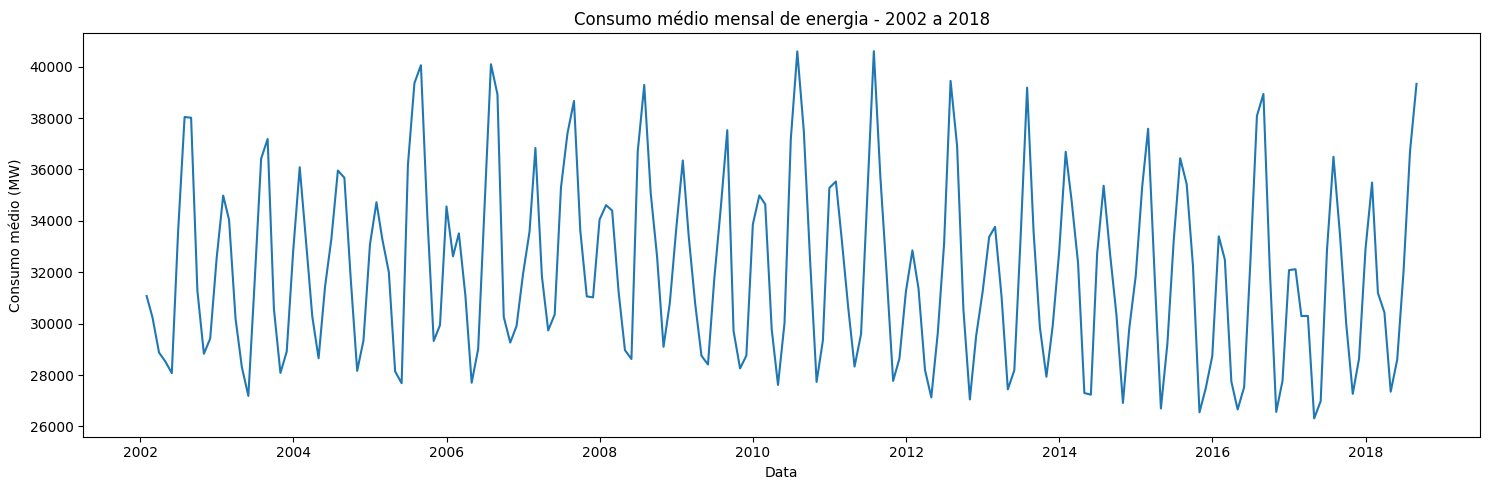

In [63]:

df["Datetime"] = pd.to_datetime(df["Datetime"]) #garante que a coluna Datetime esteja em formato data/hora

#Garantindo que o dataset está ordenado por data em ordem crescente.
df = df.sort_values("Datetime").reset_index(drop=True)

#aqui, vamos plotar o consumo médio mensal durante o período de 2002 a 2018, visto que
#plotar um gráfico com todos os 145366 dados tomaria muito tempo e processamento.

df_mensal = (
    df.set_index("Datetime")["PJME_MW"]
      .resample("ME")
      .mean()
)

'''
.set_index("Datetime") -> Define a coluna de datetime como o índice da tabela
["PJME_MW"] -> filtra apenas a coluna de consumo
.resample("ME") -> Agrupa os dados do index pelo último dia de cada mês (ME = Month End)
.mean() -> Calcula a média dos dados agrupados
'''

plt.figure(figsize=(15, 5))

plt.plot(df_mensal.index, df_mensal.values)

plt.title("Consumo médio mensal de energia - 2002 a 2018")
plt.xlabel("Data")
plt.ylabel("Consumo médio (MW)")
plt.tight_layout()

plt.show()

##5.2: Consumo médio por hora do dia

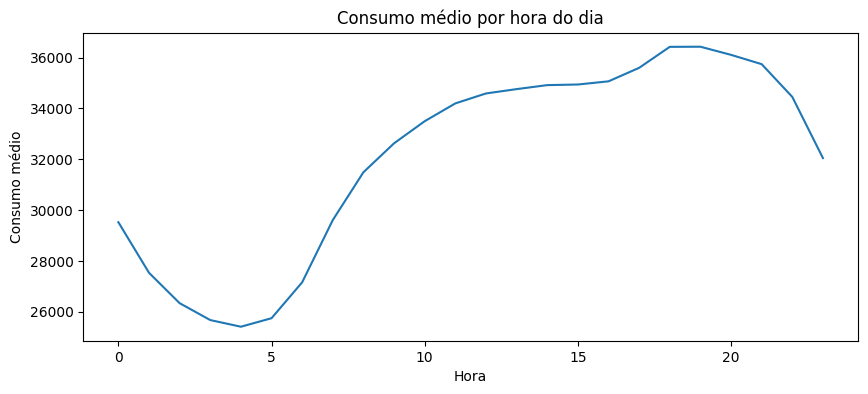

In [64]:
df["hora"] = df["Datetime"].dt.hour

media_por_hora = df.groupby("hora")["PJME_MW"].mean()

media_por_hora.plot(figsize=(10, 4))
plt.title("Consumo médio por hora do dia")
plt.xlabel("Hora")
plt.ylabel("Consumo médio")
plt.show()

Visualizando o consumo médio por hora do dia, considerando todo o período do dataset, podemos observar um claro padrão diário de consumo:

Madrugada (0h–5h): apresenta as menores médias de consumo, ficando abaixo de aproximadamente 30.000 MW e atingindo o menor valor por volta das 4h.

Manhã (5h–10h): o consumo cresce de forma acentuada, indicando o aumento da demanda ao início das atividades diárias.

Dia e início da noite (10h–19h): são observadas as maiores médias de consumo, com pico superior a 36.000 MW por volta das 18h–19h.

Noite (após 19h): o consumo começa a diminuir progressivamente, chegando a aproximadamente 32.000 MW às 23h.




**Esse comportamento evidencia um padrão sazonal diário, já que o consumo apresenta variações recorrentes de acordo com a hora do dia.**

##5.3: Consumo médio por dia da semana

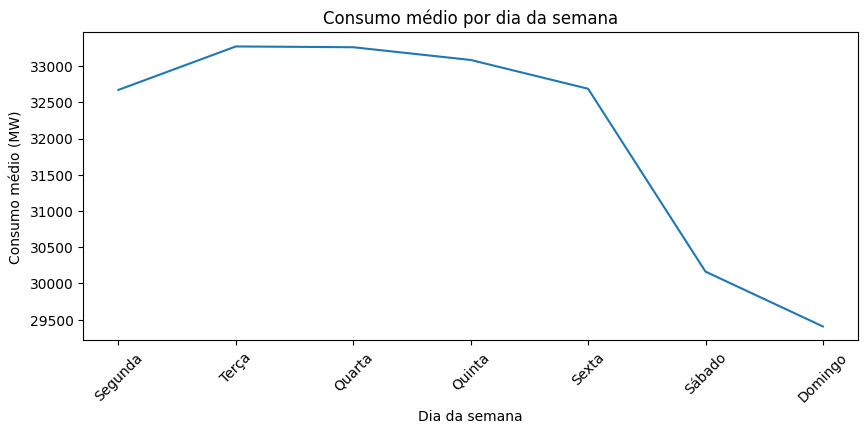

In [65]:
# Cria uma coluna com o dia da semana
df["dia_semana"] = df["Datetime"].dt.dayofweek

# Calcula o consumo médio para cada dia da semana
media_por_dia = df.groupby("dia_semana")["PJME_MW"].mean()

# Renomeia os dias para facilitar a leitura
media_por_dia.index = [
    "Segunda",
    "Terça",
    "Quarta",
    "Quinta",
    "Sexta",
    "Sábado",
    "Domingo"
]

# Gráfico
media_por_dia.plot(figsize=(10, 4))

plt.title("Consumo médio por dia da semana")
plt.xlabel("Dia da semana")
plt.ylabel("Consumo médio (MW)")
plt.xticks(rotation=45)
plt.show()

**Dias úteis (segunda a sexta-feira):** apresentam médias de consumo mais elevadas e relativamente próximas entre si, indicando maior demanda energética durante os dias de atividade normal.


**Fim de semana:** o consumo médio tende a diminuir, principalmente no sábado e no domingo, refletindo uma redução da atividade comercial, industrial e de outros setores.
Esse comportamento evidencia uma sazonalidade semanal, pois o nível de consumo varia de forma recorrente de acordo com o dia da semana.

##Seção 6: Divisão Temporal

In [66]:
#não se pode treinar a rede com dados do futuro e testar com dados do passado.
#A divisão dos dados deve ser feita em ordem cronológica, não aleatória.
#o modelo deve aprender com o passado e ser avaliado em períodos posteriores.

#Treino -> 0% a 70% dos dados (Ajustar os pesos da rede).
#Validação -> 70% a 85% dos dados (Escolher arquitetura/hiperparâmetros e acompanhar overfitting sem usar o teste).
#Teste -> 85% a 100% dos dados (Avaliação final em dados mantidos fora das decisões de treinamento).

# Mantém apenas as colunas necessárias para a modelagem
df_modelo = df[["Datetime", "PJME_MW"]].copy()

n = len(df_modelo)

# Pontos aproximados de 70% e 85%
idx_treino = int(n * 0.70)
idx_validacao = int(n * 0.85)

# Faz os cortes começarem exatamente às 00:00
corte_treino = df_modelo.iloc[idx_treino]["Datetime"].normalize()
corte_validacao = df_modelo.iloc[idx_validacao]["Datetime"].normalize()

# Divisão cronológica
treino = df_modelo[
    df_modelo["Datetime"] < corte_treino
].copy()

validacao = df_modelo[
    (df_modelo["Datetime"] >= corte_treino) &
    (df_modelo["Datetime"] < corte_validacao)
].copy()

teste = df_modelo[
    df_modelo["Datetime"] >= corte_validacao
].copy()

Por que 70/15/15 e não outra divisão? Não é uma regra matemática. É um compromisso razoável entre dar bastante histórico ao treino e ainda reservar blocos temporais independentes para validação e teste. O ponto metodológico mais importante é preservar a ordem temporal.

In [67]:
#Resultado da divisão dos dados
print("Treino:")
print("Registros:", len(treino))
print(treino["Datetime"].min(), "até", treino["Datetime"].max())

print("\nValidação:")
print("Registros:", len(validacao))
print(validacao["Datetime"].min(), "até", validacao["Datetime"].max())

print("\nTeste:")
print("Registros:", len(teste))
print(teste["Datetime"].min(), "até", teste["Datetime"].max())

Treino:
Registros: 101759
2002-01-01 01:00:00 até 2013-08-10 23:00:00

Validação:
Registros: 21816
2013-08-11 00:00:00 até 2016-02-05 23:00:00

Teste:
Registros: 21817
2016-02-06 00:00:00 até 2018-08-03 00:00:00


# Seção 7: Baseline

## 7.1 Introdução

O **baseline** é um método de previsão simples, ***sem aprendizado de máquina***, que indica quão bem o problema pode ser resolvido com uma estratégia trivial. Seu resultado serve como referência para avaliar os modelos desenvolvidos posteriormente.

### Estratégia adotada: "amanhã será igual a hoje"

Neste trabalho, o baseline utiliza uma estratégia de **previsão ingênua sazonal (*seasonal naive*)**, considerando um período de 24 horas. Assim, cada horário do dia seguinte recebe como previsão o consumo observado no mesmo horário do dia anterior. Por exemplo, o consumo previsto para amanhã às 18h será igual ao consumo registrado hoje às 18h.


In [68]:
# 7.1 Parâmetros e verificação da série de teste

# Parâmetros das janelas
JANELA_ENTRADA = 168   # horas de histórico usadas como entrada (7 dias)
HORIZONTE = 24         # horas a prever (dia seguinte)
PASSO = 24             # distância, em horas, entre o início de uma janela e da seguinte

# Série de consumo do teste
# O dataset já foi previamente corrigido na Seção 4:
# horas ausentes foram inseridas e os valores de consumo foram interpolados.
serie_teste = teste.set_index("Datetime")["PJME_MW"]

# Verificação da continuidade temporal
horas_esperadas = pd.date_range(
    start=serie_teste.index.min(),
    end=serie_teste.index.max(),
    freq="h"
)

horas_faltantes = horas_esperadas.difference(serie_teste.index)

print("Registros no teste:        ", len(serie_teste))
print("Horas esperadas no período:", len(horas_esperadas))
print("Horas faltantes:           ", len(horas_faltantes))
print("Valores NaN no teste:      ", serie_teste.isna().sum())

# A preparação dos dados deve garantir que não existam lacunas ou NaN.
assert len(horas_faltantes) == 0, "Existem horas faltantes no conjunto de teste."
assert serie_teste.notna().all(), "Existem valores NaN no conjunto de teste."

print("\nSérie de teste contínua e sem valores ausentes.")

Registros no teste:         21817
Horas esperadas no período: 21817
Horas faltantes:            0
Valores NaN no teste:       0

Série de teste contínua e sem valores ausentes.


### Ponto de atenção: olhar para horas ausentes no teste.

- Dataset: antes duplicidade, enquanto aqui o problema é lacuna temporal.
- Importante para o baseline e depois para a LSTM/GRU, porque se trabalha com janelas que assumem uma sequência horária contínua.

## 7.2 Função do baseline

In [69]:
def gerar_previsoes_baseline(serie, janela_entrada=JANELA_ENTRADA,
                             horizonte=HORIZONTE, passo=PASSO):

    valores = serie.to_numpy()
    indice_datas = serie.index

    tamanho_bloco = janela_entrada + horizonte

    y_real, y_pred, datas = [], [], []

    for inicio in range(0, len(valores) - tamanho_bloco + 1, passo):

        fim_entrada = inicio + janela_entrada
        fim_bloco = inicio + tamanho_bloco

        entrada = valores[inicio:fim_entrada]
        alvo = valores[fim_entrada:fim_bloco]

        # O tratamento de valores ausentes já foi realizado na Seção 4.
        # Caso exista algum NaN nesta etapa, há um problema na preparação dos dados.
        assert np.isfinite(entrada).all()
        assert np.isfinite(alvo).all()

        # Baseline: últimas 24h = previsão das próximas 24h
        previsao = entrada[-horizonte:]

        y_real.append(alvo)
        y_pred.append(previsao)
        datas.append(indice_datas[fim_entrada:fim_bloco])

    return np.array(y_real), np.array(y_pred), np.array(datas)

## 7.3 Previsões do baseline no conjunto de teste:


A função foi aplicada ao conjunto de teste e o seu resultado foi organizado em matrizes (cada linha representa um dia previsto e cada coluna representa uma das 24 horas desse dia).

- Por exemplo, um formato (900, 24) significa 900 dias previstos, cada um com 24 horas de previsão.

In [70]:
# 7.3 Previsões do baseline no conjunto de teste

y_real_baseline, y_pred_baseline, datas_baseline = gerar_previsoes_baseline(
    serie_teste
)

# Total de janelas avaliadas
janelas_avaliadas = len(y_real_baseline)

print("Janelas avaliadas:", janelas_avaliadas)

print("\nFormato dos valores reais:  ", y_real_baseline.shape)
print("Formato das previsões:     ", y_pred_baseline.shape)

# Período coberto pelas previsões
print("\nPrimeira hora prevista:", pd.Timestamp(datas_baseline[0, 0]))
print("Última hora prevista:  ", pd.Timestamp(datas_baseline[-1, -1]))

Janelas avaliadas: 902

Formato dos valores reais:   (902, 24)
Formato das previsões:      (902, 24)

Primeira hora prevista: 2016-02-13 00:00:00
Última hora prevista:   2018-08-02 23:00:00


## 7.4 Métricas de avaliação: MAE e RMSE

- **MAE (Erro Absoluto Médio)**: indica o erro médio entre o consumo real e o previsto.

- **RMSE (Raiz do Erro Quadrático Médio)**: dá maior peso aos erros de maior magnitude.

O MAE facilita a interpretação do erro médio, enquanto o RMSE ajuda a identificar situações em que ocorreram erros mais elevados.

- A avaliação considera 901 períodos de previsão, com 24 horas em cada período, totalizando 21.624 valores previstos.

In [71]:
# 7.4 Cálculo do MAE e do RMSE do baseline

# Diferença entre o consumo real e o previsto, hora a hora
erros_baseline = y_real_baseline - y_pred_baseline

# MAE: média dos erros em valor absoluto
mae_baseline = np.mean(np.abs(erros_baseline))

# RMSE: raiz da média dos erros ao quadrado
rmse_baseline = np.sqrt(np.mean(erros_baseline ** 2))

# Consumo médio real no período avaliado, usado como referência
consumo_medio_teste = np.mean(y_real_baseline)

print(f"MAE do baseline:  {mae_baseline:.2f} MW")
print(f"RMSE do baseline: {rmse_baseline:.2f} MW")
print(f"\nConsumo médio no período avaliado: {consumo_medio_teste:.2f} MW")
print(f"O MAE representa {mae_baseline / consumo_medio_teste * 100:.2f}% do consumo médio")

MAE do baseline:  2208.16 MW
RMSE do baseline: 3031.90 MW

Consumo médio no período avaliado: 31077.39 MW
O MAE representa 7.11% do consumo médio


Leitura dos resultados:

- O MAE de 2.208,31 MW indica que o baseline erra, em média, cerca de 2.208 MW por hora em relação ao consumo real, o equivalente a 7,11% do consumo médio.

- O RMSE de 3.032,61 MW, cerca de 37% maior que o MAE, mostra que existem erros pontuais de maior magnitude, que serão investigados nas próximas etapas.

## 7.5 Organização dos resultados: real × previsto

As previsões foram reorganizadas em uma tabela com uma linha por hora avaliada, contendo data e hora, consumo real, consumo previsto, erro, horário e dia da semana.

O erro representa quanto o consumo real ficou acima ou abaixo da previsão:
- valores **positivos** indicam que o baseline **subestimou** o consumo;
- valores **negativos**, que **superestimou**.

In [72]:
# 7.5 Tabela de resultados: consumo real × previsto

resultados_baseline_df = pd.DataFrame({
    "Datetime": pd.to_datetime(datas_baseline.ravel()),
    "consumo_real": y_real_baseline.ravel(),
    "consumo_previsto": y_pred_baseline.ravel()
})

# Erro positivo = subestimou o consumo; erro negativo = superestimou
resultados_baseline_df["erro"] = (
    resultados_baseline_df["consumo_real"] - resultados_baseline_df["consumo_previsto"]
)

# Colunas de apoio para a análise de erros por horário e dia da semana
resultados_baseline_df["hora"] = resultados_baseline_df["Datetime"].dt.hour
resultados_baseline_df["dia_semana"] = resultados_baseline_df["Datetime"].dt.dayofweek


print("Total de horas previstas:", len(resultados_baseline_df))
resultados_baseline_df.head(10)

Total de horas previstas: 21648


,Datetime,consumo_real,consumo_previsto,erro,hora,dia_semana
0,2016-02-13 00:00:00,34819.0,36634.0,-1815.0,0,5
1,2016-02-13 01:00:00,33479.0,35154.0,-1675.0,1,5
2,2016-02-13 02:00:00,32827.0,34611.0,-1784.0,2,5
3,2016-02-13 03:00:00,32610.0,34472.0,-1862.0,3,5
4,2016-02-13 04:00:00,32661.0,34686.0,-2025.0,4,5
5,2016-02-13 05:00:00,33199.0,35617.0,-2418.0,5,5
6,2016-02-13 06:00:00,34215.0,37958.0,-3743.0,6,5
7,2016-02-13 07:00:00,35697.0,41297.0,-5600.0,7,5
8,2016-02-13 08:00:00,36790.0,42477.0,-5687.0,8,5
9,2016-02-13 09:00:00,37662.0,41487.0,-3825.0,9,5


## 7.6 Visualização: consumo real × previsão do baseline

O gráfico abaixo compara o consumo real com a previsão do baseline durante uma semana do conjunto de teste (08/07/2017 a 14/07/2017).

Obs: Esse período foi escolhido por incluir a passagem do fim de semana para os dias úteis, uma das situações em que a estratégia "amanhã será igual a hoje" tende a errar mais.

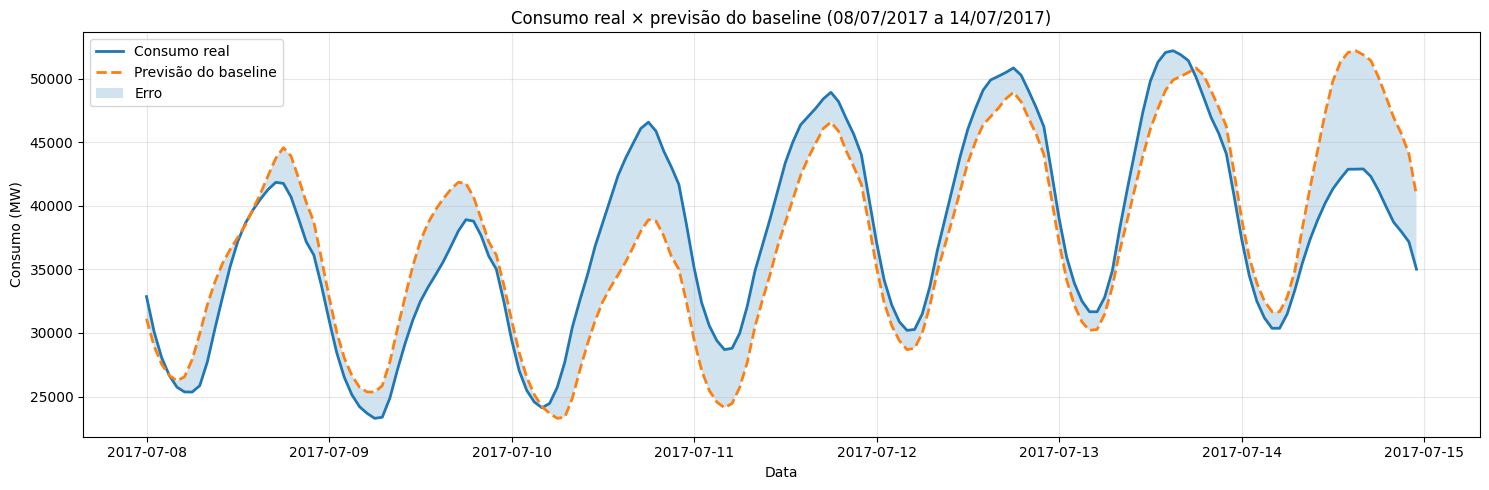

In [73]:
# 7.6 Gráfico: consumo real × previsão do baseline

# Semana exibida no gráfico (pode ser alterada para visualizar outro período)
inicio_grafico = pd.Timestamp("2017-07-08")
fim_grafico = pd.Timestamp("2017-07-15")

# Filtra a tabela de resultados para o período escolhido
periodo = resultados_baseline_df[
    (resultados_baseline_df["Datetime"] >= inicio_grafico) &
    (resultados_baseline_df["Datetime"] < fim_grafico)
]

plt.figure(figsize=(15, 5))

plt.plot(periodo["Datetime"], periodo["consumo_real"],
         label="Consumo real", linewidth=2)
plt.plot(periodo["Datetime"], periodo["consumo_previsto"],
         label="Previsão do baseline", linestyle="--", linewidth=2)

# Área entre as curvas: o erro de cada hora
plt.fill_between(periodo["Datetime"],
                 periodo["consumo_real"], periodo["consumo_previsto"],
                 alpha=0.2, label="Erro")


plt.title(f"Consumo real × previsão do baseline "
          f"({inicio_grafico:%d/%m/%Y} a {fim_grafico - pd.Timedelta(days=1):%d/%m/%Y})")
plt.xlabel("Data")
plt.ylabel("Consumo (MW)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


**Leitura do gráfico: os dois tipos de erro**

- Segunda-feira (10/07), subestimação (erro positivo): a previsão repetiu o consumo do domingo e ficou cerca de 7.500 MW abaixo do real no pico. Para a distribuidora esse é o cenário de risco de falta de energia.

- Sexta-feira (14/07), superestimação (erro negativo) a previsão repetiu uma quinta-feira de consumo elevado e ficou cerca de 9.000 MW acima do real no pico.

Para a distribuidora, esse é o cenário de custo desnecessário: usinas adicionais poderiam ser acionadas para atender a uma demanda que não se concretizou.

## 7.7 Resultados finais do baseline



In [74]:
# 7.7 Registro das métricas finais do baseline

resultados_baseline = {
    "Modelo": "Baseline (amanhã = hoje)",
    "MAE (MW)": round(mae_baseline, 2),
    "RMSE (MW)": round(rmse_baseline, 2),
    "MAE (% do consumo médio)": round(
        mae_baseline / consumo_medio_teste * 100, 2
    ),
    "Janelas avaliadas": janelas_avaliadas
}

# Exibe as métricas em formato de tabela
pd.DataFrame([resultados_baseline]).set_index("Modelo").T

Modelo,Baseline (amanhã = hoje)
MAE (MW),2208.16
RMSE (MW),3031.90
MAE (% do consumo médio),7.11
Janelas avaliadas,902.00


### Limitações:

- O baseline não aprende com os dados. Ele apenas repete o comportamento do dia anterior e, por isso, não consegue identificar mudanças entre os dias. Por exemplo, uma segunda-feira pode apresentar um comportamento diferente de um domingo("amanhã será igual a hoje"), mas o baseline continua utilizando o domingo como referência.

- O erro médio não mostra onde os maiores erros acontecem. O MAE resume o comportamento de todas as previsões, mas alguns períodos podem apresentar erros muito maiores. No gráfico da seção anterior, foram observados erros de aproximadamente 7.500 MW no pico da segunda-feira e 9.000 MW no pico da sexta-feira. Esses casos mostram que analisar apenas o erro médio não é suficiente para entender o comportamento da previsão.

# Seção 8: Normalização

## 8.1 Importância da Normalização e Riscos de Conformidade

No desenvolvimento de modelos de Deep Learning para séries temporais, a escala dos dados desempenha um papel crítico na convergência do algoritmo de otimização (como o Adam). O consumo de energia elétrica regional na série histórica do PJME apresenta valores que variam de $14.544$ MW a $62.009$ MW. Alimentar esses valores brutos diretamente em uma rede neural recorrente como a GRU pode acarretar sérias dificuldades práticas:

1. **Gradientes Explosivos ou Desaparecidos:** Funções de ativação internas da GRU (como a tangente hiperbólica e a sigmoide) possuem derivadas muito próximas de zero para valores de entrada distantes da origem. Dados de alta magnitude saturam essas funções, interrompendo o fluxo de aprendizado.
2. **Velocidade de Convergência:** O algoritmo de descida do gradiente converge de forma muito mais lenta e instável quando as features possuem escalas amplas ou muito díspares.

### O Funcionamento do `MinMaxScaler`
Para solucionar esse problema, aplicamos o **`MinMaxScaler`**, que realiza uma transformação linear limitando os dados a um intervalo fixo, geralmente entre $[0, 1]$. A fórmula aplicada para cada ponto $x$ é:

$$x_{scaled} = \frac{x - x_{min}}{x_{max} - x_{min}}$$

### Risco de Conformidade: Vazamento de Dados (*Data Leakage*)
Sob a ótica de **Risco e Conformidade Metodológica**, o erro mais comum e grave na preparação de dados é o **vazamento de dados** (*data leakage*). O vazamento ocorre quando informações pertencentes aos conjuntos de validação ou teste influenciam a preparação dos dados de treinamento.

Se fizermos o `fit` do `MinMaxScaler` sobre todo o dataset (incluindo validação e teste), os valores mínimos ($x_{min}$) e máximos ($x_{max}$) globais serão utilizados. Na prática real, o modelo não possui acesso ao futuro (validação e teste) no momento de sua implantação operacional.

Para garantir conformidade estrita:
* O estimador deve aprender os parâmetros mínimos e máximos **exclusivamente com os dados de treino** (`fit` apenas no treino).
* Os dados de validação e teste devem ser escalados utilizando estritamente os limites aprendidos no treino (`transform`), garantindo que o modelo seja avaliado sob condições reais de simulação fora do tempo de ajuste.

In [75]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# 1. Instanciando o MinMaxScaler para escala [0, 1]
scaler = MinMaxScaler(feature_range=(0, 1))

# Ajustando o scaler exclusivamente no treino e transformando
# A coluna de interesse é 'PJME_MW'
train_series = treino[['PJME_MW']].values
val_series = validacao[['PJME_MW']].values
test_series = teste[['PJME_MW']].values

# Fit e transform apenas no treino
train_scaled = scaler.fit_transform(train_series)

# Apenas transform nos conjuntos de validação e teste (evitando Data Leakage)
val_scaled = scaler.transform(val_series)
test_scaled = scaler.transform(test_series)

print("Limites aprendidos no treino pelo scaler:")
print(f"Mínimo original: {scaler.data_min_[0]} MW")
print(f"Máximo original: {scaler.data_max_[0]} MW\n")

print(f"Formato treino normalizado: {train_scaled.shape}")
print(f"Formato validação normalizada: {val_scaled.shape}")
print(f"Formato teste normalizado: {test_scaled.shape}")

Limites aprendidos no treino pelo scaler:
Mínimo original: 14544.0 MW
Máximo original: 62009.0 MW

Formato treino normalizado: (101759, 1)
Formato validação normalizada: (21816, 1)
Formato teste normalizado: (21817, 1)


# Seção 9: Criação das Sequências

## 9.1 O Conceito de Janela Temporal e Estrutura de Entrada da GRU

Para modelar um problema de previsão de séries temporais como aprendizado supervisionado, aplicamos o conceito de **Janela Deslizante** (*Sliding Window*).

### Decisão de Projeto: Janela de Entrada de 168h e Horizonte de 24h
Nossa estratégia de modelagem baseia-se em analisar os padrões cíclicos de consumo estabelecidos nas análises exploratórias preliminares:
* **Janela de Entrada (Histórico): 168 horas (7 dias consecutivos).** Essa decisão de projeto é robusta pois cobre as duas principais sazonalidades identificadas no consumo PJME: a sazonalidade diária (padrão de comportamento de 24 horas) e a sazonalidade semanal (diferença nítida entre dias úteis e finais de semana).
* **Janela de Saída (Horizonte de Previsão): 24 horas (dia seguinte).** Nosso objetivo final é planejar a operação do despacho energético para o dia seguinte completo de uma só vez.

Com um avanço (passo) de 24 horas, o modelo se desloca dia após dia ao longo do tempo.

### O Formato Tridimensional Esperado pela GRU

As redes neurais recorrentes, como a GRU, exigem que as entradas sejam representadas em um formato tridimensional:

$$\text{Formato} = (\text{Batch Size}, \text{Timesteps}, \text{Features})$$

No nosso contexto:
1. **Batch Size (Amostras):** O número total de sequências de 7 dias que conseguiremos extrair da série temporal.
2. **Timesteps (Passos Temporais):** $168$, indicando as observações de horas consecutivas que formam a nossa sequência de entrada histórica.
3. **Features (Variáveis de entrada):** $1$, correspondente à única variável monitorada (o consumo de energia elétrica normalizado).

In [76]:
import numpy as np

def criar_sequencias_temporais(dados_escalados, janela_entrada=168, horizonte=24, passo=24):
    """
    Gera matrizes 3D de entrada (X) e 2D de alvos (y) utilizando o método de janela deslizante.
    """
    X, y = [], []
    tamanho_bloco = janela_entrada + horizonte

    # Cria sequências ao longo da série temporal utilizando o passo definido
    for i in range(0, len(dados_escalados) - tamanho_bloco + 1, passo):
        entrada = dados_escalados[i : i + janela_entrada]
        alvo = dados_escalados[i + janela_entrada : i + tamanho_bloco]

        X.append(entrada)
        y.append(alvo.ravel()) # Garante vetor de 24 posições planas para a saída

    return np.array(X), np.array(y)

# 1. Definindo os diferentes passos para Data Augmentation no treino e simulação real na avaliação
PASSO_TREINO = 1 # IMPORTANTE: Se o Colab travar por falta de RAM, mude este valor para 6
PASSO_AVALIACAO = 24

# 2. Gerando as sequências
X_train, y_train = criar_sequencias_temporais(train_scaled, JANELA_ENTRADA, HORIZONTE, PASSO_TREINO)
X_val, y_val = criar_sequencias_temporais(val_scaled, JANELA_ENTRADA, HORIZONTE, PASSO_AVALIACAO)
X_test_justo, y_test_justo = criar_sequencias_temporais(test_scaled, JANELA_ENTRADA, HORIZONTE, PASSO_AVALIACAO)

# 3. Salvando as datas correspondentes ao teste justo (utilizando PASSO_AVALIACAO)
datas_test_justo = []
datas_serie_teste = teste["Datetime"].values

for i in range(0, len(datas_serie_teste) - (JANELA_ENTRADA + HORIZONTE) + 1, PASSO_AVALIACAO):
    datas_test_justo.append(datas_serie_teste[i + JANELA_ENTRADA : i + JANELA_ENTRADA + HORIZONTE])

datas_test_justo = np.array(datas_test_justo)

# 4. Diagnósticos de execução
print("=== Dimensões das Sequências Criadas ===\n")
print(f"Treino     - X: {X_train.shape} | y: {y_train.shape}")
print(f"Validação  - X: {X_val.shape}  | y: {y_val.shape}")
print(f"Teste      - X: {X_test_justo.shape}  | y: {y_test_justo.shape}")

print("\n=== Primeira hora prevista de cada conjunto ===")
print("Treino:", treino.iloc[JANELA_ENTRADA]["Datetime"])
print("Validação:", validacao.iloc[JANELA_ENTRADA]["Datetime"])
print("Teste:", teste.iloc[JANELA_ENTRADA]["Datetime"])

print("\n=== Faixa dos dados normalizados ===")
print("Treino:", train_scaled.min(), "até", train_scaled.max())
print("Validação:", val_scaled.min(), "até", val_scaled.max())
print("Teste:", test_scaled.min(), "até", test_scaled.max())

=== Dimensões das Sequências Criadas ===

Treino     - X: (101568, 168, 1) | y: (101568, 24)
Validação  - X: (902, 168, 1)  | y: (902, 24)
Teste      - X: (902, 168, 1)  | y: (902, 24)

=== Primeira hora prevista de cada conjunto ===
Treino: 2002-01-08 01:00:00
Validação: 2013-08-18 00:00:00
Teste: 2016-02-13 00:00:00

=== Faixa dos dados normalizados ===
Treino: 0.0 até 1.0
Validação: 0.10336037079953653 até 0.8550510902770463
Teste: 0.09925208048035394 até 0.8862319603918676


# Seção 10: Modelo

## 10.1 Exploração e definição da arquitetura

Foram realizados testes preliminares com diferentes tamanhos de camada GRU (32, 64 e 128 unidades), mantendo os demais parâmetros constantes. A arquitetura utilizada foi uma camada GRU, seguida de Dropout (0,2) e uma camada Dense com 24 neurônios, correspondente ao horizonte de previsão.

Em todos os testes foram utilizados: janela de entrada de 168 horas, horizonte de 24 horas, Adam, MSE, batch size de 32 e 20 épocas.

| Configuração | Melhor `val_mae` | Época |
|---|---:|---:|
| GRU 32 | 0,04854 | 20 |
| GRU 64 | 0,03913 | 20 |
| GRU 128 | 0,03694 | 17 |

A GRU com 128 unidades apresentou o menor MAE de validação entre as configurações testadas. Como o desempenho de validação começou a piorar após a melhor época nessa configuração, foi utilizado `EarlyStopping` no treinamento final.

Assim, a arquitetura final definida foi uma GRU com 128 unidades, Dropout de 0,2 e Dense com 24 neurônios.
    

***********************************

#### A arquitetura final utilizada foi composta por uma camada de entrada para as sequências de 168 horas, uma camada GRU com 128 unidades, uma camada Dropout para regularização e uma camada Dense com 24 neurônios, correspondentes às 24 horas que devem ser previstas.



In [77]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, GRU, Dropout, Dense

model_final = Sequential([
    Input(shape=(JANELA_ENTRADA, 1)),
    GRU(128),
    Dropout(0.2),
    Dense(HORIZONTE)
])

model_final.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

model_final.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_1 (GRU)                     │ (None, 128)            │        50,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24)             │         3,096 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,400 (208.59 KB)

 Trainable params: 53,400 (208.59 KB)

 Non-trainable params: 0 (0.00 B)

# Seção 11 - Treinamento

## 11.1 Dados utilizados pela rede

A rede foi treinada com sequências temporais construídas a partir dos dados normalizados. Cada entrada contém as 168 horas anteriores de consumo (uma semana), e o alvo contém as 24 horas seguintes a serem previstas.

Os dados foram divididos cronologicamente em treinamento, validação e teste, evitando o uso de informações futuras durante o treinamento. O conjunto de validação foi utilizado para acompanhar o desempenho durante o treinamento, enquanto o teste foi mantido separado para a avaliação final.

As dimensões utilizadas foram:


| Conjunto | Entrada X | Alvo y |
|---|---|---|
| Treinamento | `(4232, 168, 1)` | `(4232, 24)` |
| Validação | `(908, 168, 1)` | `(908, 24)` |
| Teste* | `(877, 168, 1)` | `(877, 24)` |

O passo de 24 horas faz com que as amostras avancem um dia no tempo.

\* Foram consideradas 877 janelas válidas no conjunto de teste. Algumas janelas foram descartadas por conterem horários ausentes. O mesmo critério foi aplicado ao baseline para garantir uma comparação justa.

## 11.2 Configuração de treinamento

O treinamento foi realizado utilizando o **otimizador Adam**, a função de perda **MSE** e o **MAE** como métrica de acompanhamento. A MSE foi escolhida por penalizar mais fortemente erros de maior magnitude, enquanto o MAE permite acompanhar diretamente a magnitude média dos erros.

O treinamento foi configurado para **até 30 épocas, com batch size de 32**. Para evitar treinamento desnecessário e reduzir o risco de overfitting, foi utilizado o **EarlyStopping**, monitorando o `val_loss`, com `patience=3`.

O parâmetro `restore_best_weights=True` garante que, ao final do treinamento, sejam mantidos os pesos da época que apresentou o melhor resultado de validação.

In [78]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history_final = model_final.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/30
3174/3174 ━━━━━━━━━━━━━━━━━━━━ 38s 11ms/step - loss: 0.0050 - mae: 0.0516 - val_loss: 0.0026 - val_mae: 0.0380
Epoch 2/30
3174/3174 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step - loss: 0.0026 - mae: 0.0383 - val_loss: 0.0029 - val_mae: 0.0412
Epoch 3/30
3174/3174 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step - loss: 0.0022 - mae: 0.0351 - val_loss: 0.0023 - val_mae: 0.0341
Epoch 4/30
3174/3174 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step - loss: 0.0019 - mae: 0.0325 - val_loss: 0.0018 - val_mae: 0.0303
Epoch 5/30
3174/3174 ━━━━━━━━━━━━━━━━━━━━ 30s 10ms/step - loss: 0.0018 - mae: 0.0309 - val_loss: 0.0017 - val_mae: 0.0288
Epoch 6/30
3174/3174 ━━━━━━━━━━━━━━━━━━━━ 28s 9ms/step - loss: 0.0017 - mae: 0.0300 - val_loss: 0.0018 - val_mae: 0.0316
Epoch 7/30
3174/3174 ━━━━━━━━━━━━━━━━━━━━ 28s 9ms/step - loss: 0.0016 - mae: 0.0293 - val_loss: 0.0015 - val_mae: 0.0269
Epoch 8/30
3174/3174 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - loss: 0.0016 - mae: 0.0288 - val_loss: 0.0017 - val_mae: 0.0287
Epoch 9/30
3174/3174 ━━━━━━━━━

**Leitura dos resultados:**

O treinamento foi executado por até 30 épocas, utilizando EarlyStopping para interromper o processo caso o desempenho no conjunto de validação deixasse de apresentar melhorias.

A quantidade efetiva de épocas executadas e a época correspondente ao melhor desempenho podem variar entre diferentes execuções, devido às características estocásticas do treinamento de redes neurais. O histórico gerado pelo treinamento permite identificar esses valores para cada execução.

Como foi utilizado `restore_best_weights=True`, o modelo mantido ao final do treinamento utiliza os pesos correspondentes ao melhor desempenho de validação observado durante a execução.

O histórico de treinamento também permite acompanhar a evolução das métricas de treinamento e validação e verificar se o modelo continua apresentando melhoria ou se começa a apresentar sinais de perda de generalização.

## 11.3 Evolução da função de perda

O histórico de treinamento pode ser utilizado para visualizar a evolução do erro nos conjuntos de treinamento e validação.

- **`loss`:** MSE calculada no conjunto de treinamento.
- **`val_loss`:** MSE calculada no conjunto de validação.

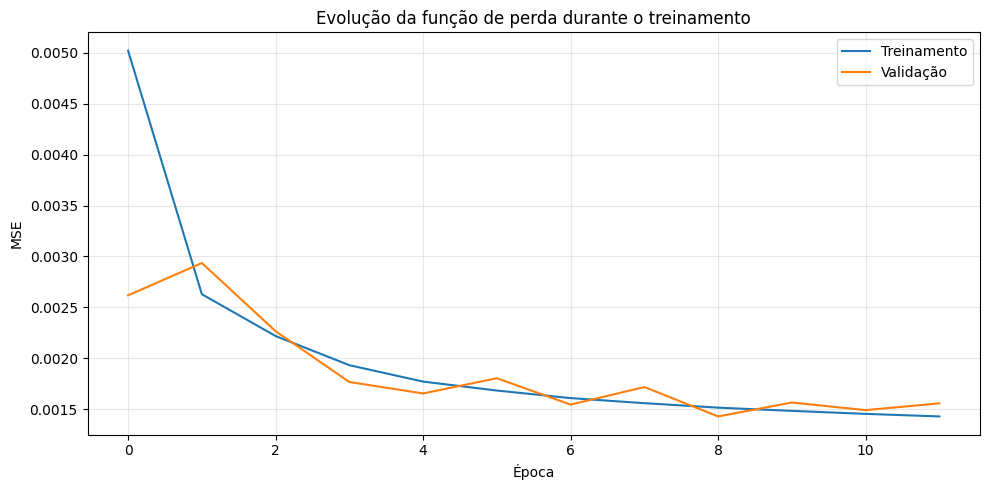

In [79]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    history_final.history["loss"],
    label="Treinamento"
)

plt.plot(
    history_final.history["val_loss"],
    label="Validação"
)

plt.xlabel("Época")
plt.ylabel("MSE")
plt.title("Evolução da função de perda durante o treinamento")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Leitura do gráfico:** A redução de ambas as curvas indica melhora do modelo. Se a `loss` continuar diminuindo enquanto a `val_loss` começar a aumentar, pode haver sinal de overfitting. O `EarlyStopping` utiliza justamente o `val_loss` para identificar quando o desempenho de validação deixa de melhorar.

## 11.4 Evolução do MAE

A evolução do MAE permite acompanhar a redução do erro médio ao longo do treinamento e comparar o comportamento do modelo nos conjuntos de treinamento e validação, ajudando a identificar possíveis sinais de overfitting.

- **MAE de treinamento:** mostra o erro do modelo sobre os dados utilizados para ajustar seus pesos.
- **MAE de validação:** mostra o erro sobre dados que não são utilizados diretamente para atualizar os pesos, permitindo acompanhar a capacidade de generalização.

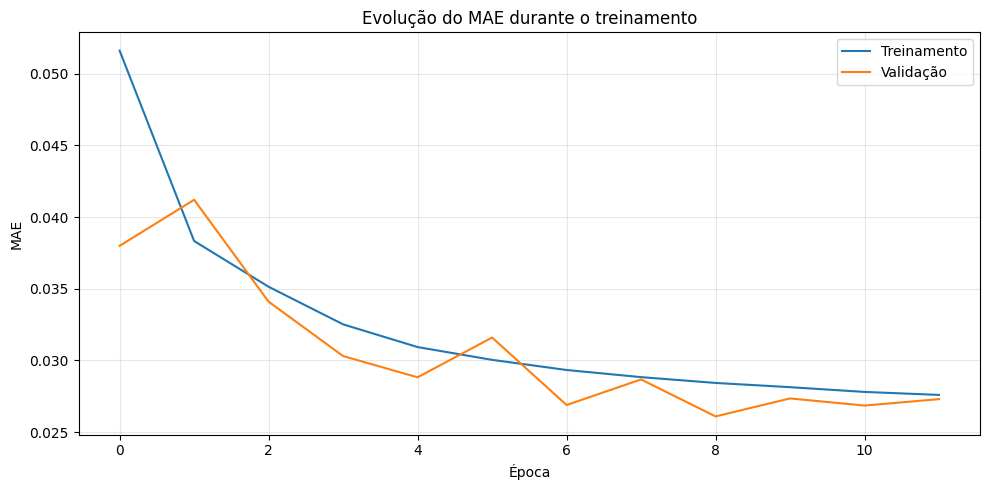

In [80]:
plt.figure(figsize=(10, 5))

plt.plot(
    history_final.history["mae"],
    label="Treinamento"
)

plt.plot(
    history_final.history["val_mae"],
    label="Validação"
)

plt.xlabel("Época")
plt.ylabel("MAE")
plt.title("Evolução do MAE durante o treinamento")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Leitura do gráfico:** De forma geral, espera-se que ambas as curvas apresentem redução ao longo das épocas. Quando o `mae` de treinamento continua diminuindo enquanto o `val_mae` começa a aumentar, isso pode indicar **overfitting**. Já uma redução de ambas as curvas indica que o modelo continua melhorando tanto nos dados de treinamento quanto na validação.

A diferença entre as duas curvas também pode ser observada para avaliar o comportamento do modelo durante o treinamento.

11.5 Geração das previsões

In [81]:
y_pred_128_es = model_final.predict(X_test_justo)

29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


# Seção 12: Avaliação
Nesta etapa, o modelo GRU treinado é avaliado utilizando o conjunto de teste, que foi mantido separado durante o treinamento.

As previsões são comparadas com os valores reais de consumo utilizando as métricas MAE e RMSE. Como o modelo foi treinado com dados normalizados, precisamos converter os valores para a escala original em MW antes do cálculo das métricas.

A avaliação utiliza as mesmas janelas temporais consideradas pelo baseline, garantindo uma comparação justa entre os dois métodos.

## 12.1 Desnormalização das previsões e valores reais
Como mencionado anteriormente, os valores de consumo foram normalizados para facilitar o aprendizado da rede.

Antes de calcular as métricas finais, convertemos as previsões e os valores reais para a escala original de consumo em MW.

In [82]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

y_real_gru_norm = y_test_justo

# Salva o formato original
formato_pred = y_pred_128_es.shape
formato_real = y_real_gru_norm.shape

y_pred_gru = scaler.inverse_transform(
    y_pred_128_es.reshape(-1, 1)
).reshape(formato_pred)

y_real_gru = scaler.inverse_transform(
    y_real_gru_norm.reshape(-1, 1)
).reshape(formato_real)

print("Formato dos valores reais:", y_real_gru.shape)
print("Formato das previsões:", y_pred_gru.shape)

Formato dos valores reais: (902, 24)
Formato das previsões: (902, 24)


## 12.2 Cálculo do MAE e RMSE da GRU
O desempenho da GRU é avaliado utilizando as mesmas métricas empregadas no baseline:
* **MAE (Erro Absoluto Médio):** representa, em média, quantos MW separam o valor previsto do consumo real.
* **RMSE (Raiz do Erro Quadrático Médio):** penaliza mais fortemente erros de maior magnitude.

A utilização dessas métricas permite avaliar tanto o erro médio do modelo quanto a ocorrência de previsões com desvios elevados.

In [83]:
# Erro positivo = subestimação
# Erro negativo = superestimação
erros_gru = y_real_gru - y_pred_gru

mae_gru = np.mean(np.abs(erros_gru))
rmse_gru = np.sqrt(np.mean(erros_gru ** 2))

consumo_medio_gru = np.mean(y_real_gru)

mae_percentual_gru = (
    mae_gru / consumo_medio_gru * 100
)

print(f"MAE da GRU:  {mae_gru:.2f} MW")
print(f"RMSE da GRU: {rmse_gru:.2f} MW")

print(f"\nConsumo médio no período avaliado: {consumo_medio_gru:.2f} MW")

print(
    f"O MAE representa {mae_percentual_gru:.2f}% "
    f"do consumo médio"
)

MAE da GRU:  1388.78 MW
RMSE da GRU: 2011.09 MW

Consumo médio no período avaliado: 31077.39 MW
O MAE representa 4.47% do consumo médio


## 12.3 Registro das métricas finais da GRU
Métricas finais da GRU organizadas em uma tabela, facilitando a visualização.

Além do MAE e do RMSE em MW, também calculamos a relação entre o MAE e o consumo médio do período avaliado, permitindo interpretar o erro de forma relativa à magnitude típica da demanda.

In [84]:
resultados_gru = {
    "Modelo": "GRU",
    "MAE (MW)": round(mae_gru, 2),
    "RMSE (MW)": round(rmse_gru, 2),
    "MAE (% do consumo médio)": round(mae_percentual_gru, 2),
    "Janelas avaliadas": len(y_real_gru)
}

pd.DataFrame([resultados_gru]).set_index("Modelo").T

Modelo,GRU
MAE (MW),1388.78
RMSE (MW),2011.09
MAE (% do consumo médio),4.47
Janelas avaliadas,902.00


## 12.4 Criação da tabela de resultados da GRU


In [85]:
resultados_gru_df = pd.DataFrame({
    "Datetime": pd.to_datetime(datas_test_justo.ravel()),
    "consumo_real": y_real_gru.ravel(),
    "consumo_previsto": y_pred_gru.ravel()
})

resultados_gru_df["erro"] = (
    resultados_gru_df["consumo_real"]
    - resultados_gru_df["consumo_previsto"]
)

resultados_gru_df["erro_absoluto"] = np.abs(
    resultados_gru_df["erro"]
)

resultados_gru_df["hora"] = (
    resultados_gru_df["Datetime"].dt.hour
)

resultados_gru_df["dia_semana"] = (
    resultados_gru_df["Datetime"].dt.dayofweek
)

print(
    "Total de horas previstas:",
    len(resultados_gru_df)
)

resultados_gru_df.head(10)

Total de horas previstas: 21648


,Datetime,consumo_real,consumo_previsto,erro,erro_absoluto,hora,dia_semana
0,2016-02-13 00:00:00,34819.0,34770.039062,48.960938,48.960938,0,5
1,2016-02-13 01:00:00,33479.0,33290.500000,188.500000,188.500000,1,5
2,2016-02-13 02:00:00,32827.0,32171.892578,655.107422,655.107422,2,5
3,2016-02-13 03:00:00,32610.0,31664.142578,945.857422,945.857422,3,5
4,2016-02-13 04:00:00,32661.0,31884.445312,776.554688,776.554688,4,5
5,2016-02-13 05:00:00,33199.0,32871.687500,327.312500,327.312500,5,5
6,2016-02-13 06:00:00,34215.0,34476.710938,-261.710938,261.710938,6,5
7,2016-02-13 07:00:00,35697.0,36241.589844,-544.589844,544.589844,7,5
8,2016-02-13 08:00:00,36790.0,37447.957031,-657.957031,657.957031,8,5
9,2016-02-13 09:00:00,37662.0,37642.222656,19.777344,19.777344,9,5


Erro = consumo real - consumo previsto
* Valores positivos indicam que a GRU subestimou a demanda;
* Valores negativos indicam que a GRU superestimou a demanda;

## 12.5 Gráfico: consumo real x previsão da GRU
O gráfico abaixo compara o consumo real com as previsões realizads pela GRU durante uma semana do conjunto de teste.

Foi utilizado o mesmo período apresentado na análise do baseline, permitindo observar visualmente como os dois métodos se comportam diante das mesmas variações de consumo.

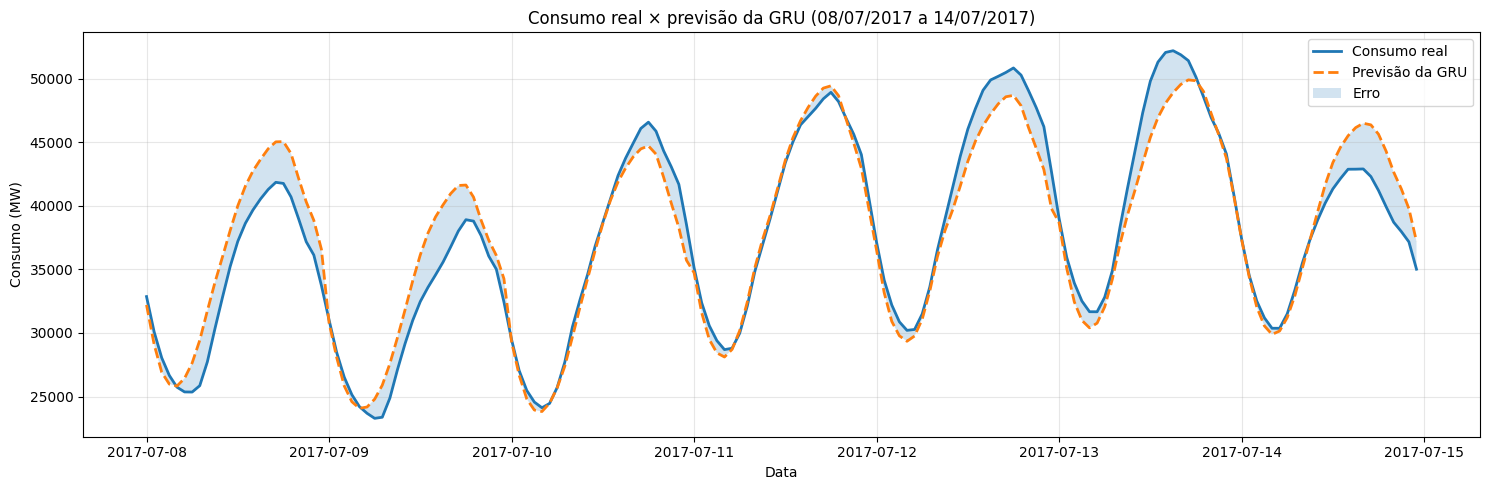

In [86]:
inicio_grafico = pd.Timestamp("2017-07-08")
fim_grafico = pd.Timestamp("2017-07-15")

periodo_gru = resultados_gru_df[
    (resultados_gru_df["Datetime"] >= inicio_grafico) &
    (resultados_gru_df["Datetime"] < fim_grafico)
]

plt.figure(figsize=(15, 5))

plt.plot(
    periodo_gru["Datetime"],
    periodo_gru["consumo_real"],
    label="Consumo real",
    linewidth=2
)

plt.plot(
    periodo_gru["Datetime"],
    periodo_gru["consumo_previsto"],
    label="Previsão da GRU",
    linestyle="--",
    linewidth=2
)

plt.fill_between(
    periodo_gru["Datetime"],
    periodo_gru["consumo_real"],
    periodo_gru["consumo_previsto"],
    alpha=0.2,
    label="Erro"
)

plt.title(
    f"Consumo real × previsão da GRU "
    f"({inicio_grafico:%d/%m/%Y} a "
    f"{fim_grafico - pd.Timedelta(days=1):%d/%m/%Y})"
)

plt.xlabel("Data")
plt.ylabel("Consumo (MW)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Seção 13: Comparação GRU x baseline
Após avaliar a GRU individualmente, comparamos seu desempenho com o baseline "amanhã será igual a hoje".

O objetivo deste etapa é verificar se a GRU consegue aprender padrões temporais que resultem em previsões mais precisas do que uma estratégia simples baseada apenas no consumo do dia anterior.

## 13.1 Tabela comparativa
Os valores de MAE e RMSE da GRU e do baseline são apresentados em conjunto.

Um valor menor indica melhor desempenho, representando uma menor diferença entre o consumo previsto e o consumo efetivamente observado.

Ao comparar as duas métricas, podemos verificar se a diferença entre os modelos ocorre apenas no erro médio ou também na ocorrência de erros de maior magnitude.

In [87]:
mesmas_datas = np.array_equal(
    pd.to_datetime(datas_test_justo.ravel()),
    pd.to_datetime(datas_baseline.ravel())
)

mesmos_reais = np.allclose(
    y_real_gru.ravel(),
    y_real_baseline.ravel()
)

print(
    "Mesmos timestamps:",
    mesmas_datas
)

print(
    "Mesmos valores reais:",
    mesmos_reais
)

Mesmos timestamps: True
Mesmos valores reais: True


In [88]:
comparacao_modelos = pd.DataFrame([
    {
        "Modelo": "Baseline",
        "MAE (MW)": mae_baseline,
        "RMSE (MW)": rmse_baseline
    },
    {
        "Modelo": "GRU",
        "MAE (MW)": mae_gru,
        "RMSE (MW)": rmse_gru
    }
])

comparacao_modelos

,Modelo,MAE (MW),RMSE (MW)
0,Baseline,2208.155349,3031.900878
1,GRU,1388.777142,2011.088597


## 13.2 Melhoria percentual da GRU
Além da comparação direta das métricas, calculamos a variação percentual do erro da GRU em relação ao baseline.

Um valor positivo indica redução do erro pela GRU, enquanto um valor negativo indica que o modelo apresentou erro maior que o baseline.

In [89]:
melhoria_mae = (
    (mae_baseline - mae_gru)
    / mae_baseline
    * 100
)

melhoria_rmse = (
    (rmse_baseline - rmse_gru)
    / rmse_baseline
    * 100
)

print(
    f"Melhoria da GRU em relação ao baseline no MAE: "
    f"{melhoria_mae:.2f}%"
)

print(
    f"Melhoria da GRU em relação ao baseline no RMSE: "
    f"{melhoria_rmse:.2f}%"
)

Melhoria da GRU em relação ao baseline no MAE: 37.11%
Melhoria da GRU em relação ao baseline no RMSE: 33.67%


## 13.3 Gráfico comparando as métricas

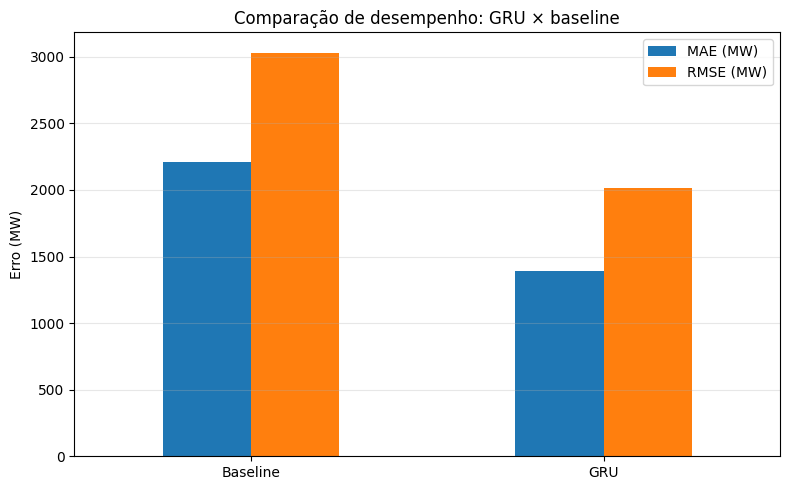

In [90]:
comparacao_plot = comparacao_modelos.set_index("Modelo")

comparacao_plot.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Comparação de desempenho: GRU × baseline")
plt.ylabel("Erro (MW)")
plt.xlabel("")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 13.4 Comparação visual GRU x baseline
O gráfico apresenta, para o mesmo período, o consumo real, a previsão do baseline e a previsão da GRU.

Essa comparação permite observar como cada abordagem acompanha as oscilações da demanda ao longo do tempo.

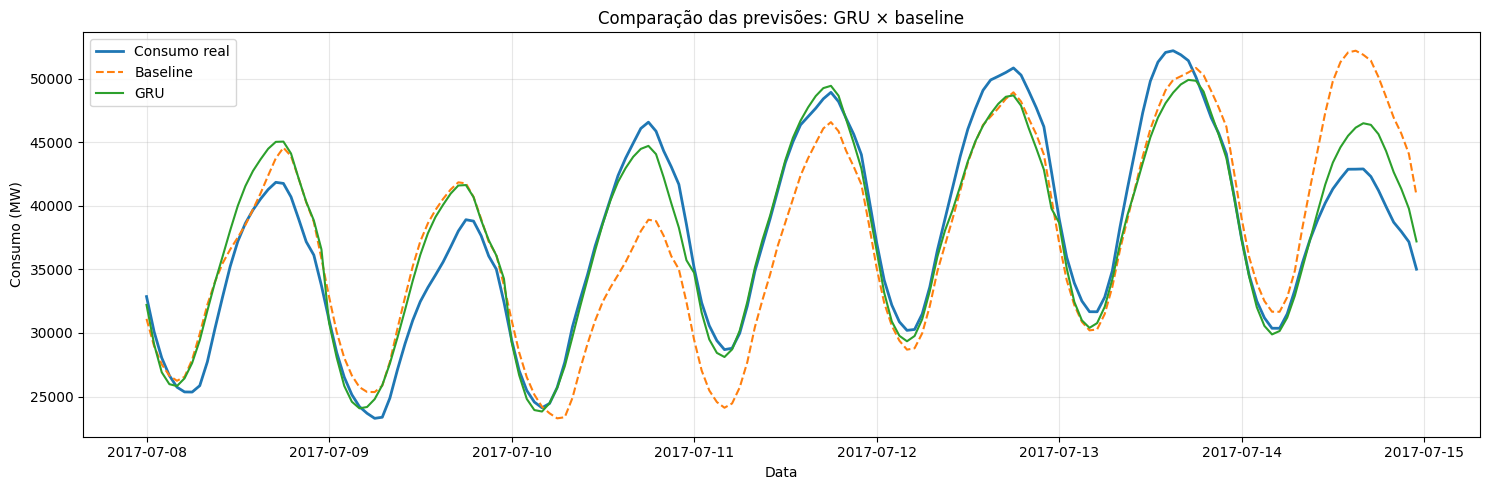

In [91]:
# Seleciona o mesmo período
periodo_baseline = resultados_baseline_df[
    (resultados_baseline_df["Datetime"] >= inicio_grafico) &
    (resultados_baseline_df["Datetime"] < fim_grafico)
]

periodo_gru = resultados_gru_df[
    (resultados_gru_df["Datetime"] >= inicio_grafico) &
    (resultados_gru_df["Datetime"] < fim_grafico)
]

plt.figure(figsize=(15, 5))

plt.plot(
    periodo_gru["Datetime"],
    periodo_gru["consumo_real"],
    label="Consumo real",
    linewidth=2
)

plt.plot(
    periodo_baseline["Datetime"],
    periodo_baseline["consumo_previsto"],
    label="Baseline",
    linestyle="--"
)

plt.plot(
    periodo_gru["Datetime"],
    periodo_gru["consumo_previsto"],
    label="GRU"
)

plt.title("Comparação das previsões: GRU × baseline")

plt.xlabel("Data")
plt.ylabel("Consumo (MW)")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Seção 14: Análise de erros
Nesta etapa, analisamos os erros sob diferentes perspectivas, considerando subestimações e superestimações, horário do dia, dia da semana, períodos de maior erro, picos de consumo e distância do horizonte de previsão.

## 14.1 Subestimações e superestimações
Separamos as previsões entre casos de subestimação e superestimação.
* Subestimação: ocorre quando o consumo real é maior que o previsto.
* Superestimação: ocorre quando o consumo previsto é maior que o consumo real.

No contexto do problema, é importante fazer essa distinção, pois os dois tipos de rros possuem consequências diferentes.

Subestimar a demanda pode fazer com que a capacidade de geração programada seja insuficiente, acarretando em apagões.

Superestimar a demanda pode levar ao acionamento de usinas caras sem necessidade.

In [92]:
qtd_subestimacoes = (
    resultados_gru_df["erro"] > 0
).sum()

qtd_superestimacoes = (
    resultados_gru_df["erro"] < 0
).sum()

qtd_exatas = (
    resultados_gru_df["erro"] == 0
).sum()

total = len(resultados_gru_df)

print("Subestimações:", qtd_subestimacoes)
print("Superestimações:", qtd_superestimacoes)
print("Previsões exatas:", qtd_exatas)

print(
    f"\nPercentual de subestimações: "
    f"{qtd_subestimacoes / total * 100:.2f}%"
)

print(
    f"Percentual de superestimações: "
    f"{qtd_superestimacoes / total * 100:.2f}%"
)

Subestimações: 9163
Superestimações: 12485
Previsões exatas: 0

Percentual de subestimações: 42.33%
Percentual de superestimações: 57.67%


## 14.2 Magnitude média das subestimações e superestimações
Além da quantidade de ocorrências, analisamos a magnitude média dos dois tipos de erro.

Essa análise permite verificar se o modelo apresenta apenas pequenas diferenças frequentes ou se determinados tipos de erro tendem a apresentar desvios maiores.

No contexto operacional, uma grande subestimação pode ser mais crítica do que várias pequenas diferenças distribuídas ao longo do tempo.

In [93]:
subestimacoes = resultados_gru_df[
    resultados_gru_df["erro"] > 0
]

superestimacoes = resultados_gru_df[
    resultados_gru_df["erro"] < 0
]

erro_medio_subestimacao = (
    subestimacoes["erro"].mean()
)

erro_medio_superestimacao = (
    np.abs(superestimacoes["erro"]).mean()
)

print(
    f"Subestimação média: "
    f"{erro_medio_subestimacao:.2f} MW"
)

print(
    f"Superestimação média: "
    f"{erro_medio_superestimacao:.2f} MW"
)

Subestimação média: 1354.11 MW
Superestimação média: 1414.22 MW


## 14.3 Erro por horário do dia
Calculamos o erro absoluto médio separadamente para cada hora do dia.

Essa análise permite identificar se o desempenho da GRU varia conforme o horário, especialmente durante períodos de aumento ou redução rápida da demanda.

In [94]:
erro_por_hora = (
    resultados_gru_df
    .groupby("hora")["erro_absoluto"]
    .mean()
)

erro_por_hora

,erro_absoluto
hora,
0,230.492608
1,395.957235
2,517.120786
3,589.759170
4,685.500269
5,885.083714
6,937.547105
7,1054.464920
8,1143.543999


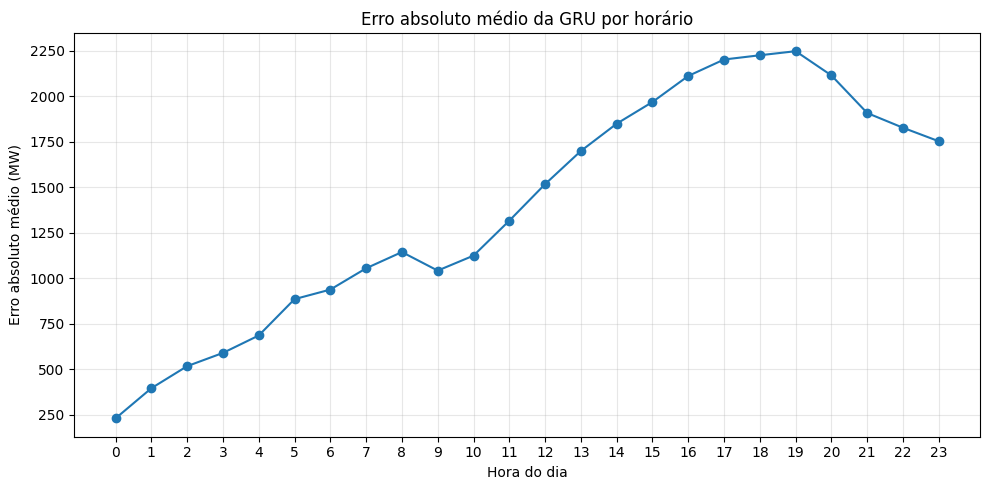

In [95]:
plt.figure(figsize=(10, 5))

plt.plot(
    erro_por_hora.index,
    erro_por_hora.values,
    marker="o"
)

plt.title("Erro absoluto médio da GRU por horário")
plt.xlabel("Hora do dia")
plt.ylabel("Erro absoluto médio (MW)")
plt.xticks(range(24))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 14.4 Erro por dia da semana
Também calculamos o erro absoluto médio de acordo com o dia da semana, já que o consumo de energia pode apresentar padrões distintos entre dias úteis e finais de semana.

Essa análise permite verificar se a GRU apresenta maior dificuldade em determinados dias ou durante transições entre diferentes padrões semanais.

In [96]:
nomes_dias = {
    0: "Segunda",
    1: "Terça",
    2: "Quarta",
    3: "Quinta",
    4: "Sexta",
    5: "Sábado",
    6: "Domingo"
}

erro_por_dia = (
    resultados_gru_df
    .groupby("dia_semana")["erro_absoluto"]
    .mean()
)

erro_por_dia.index = [
    nomes_dias[dia]
    for dia in erro_por_dia.index
]

erro_por_dia

,erro_absoluto
Segunda,1543.020671
Terça,1265.179736
Quarta,1288.249148
Quinta,1369.453842
Sexta,1263.834695
Sábado,1563.546220
Domingo,1427.187135


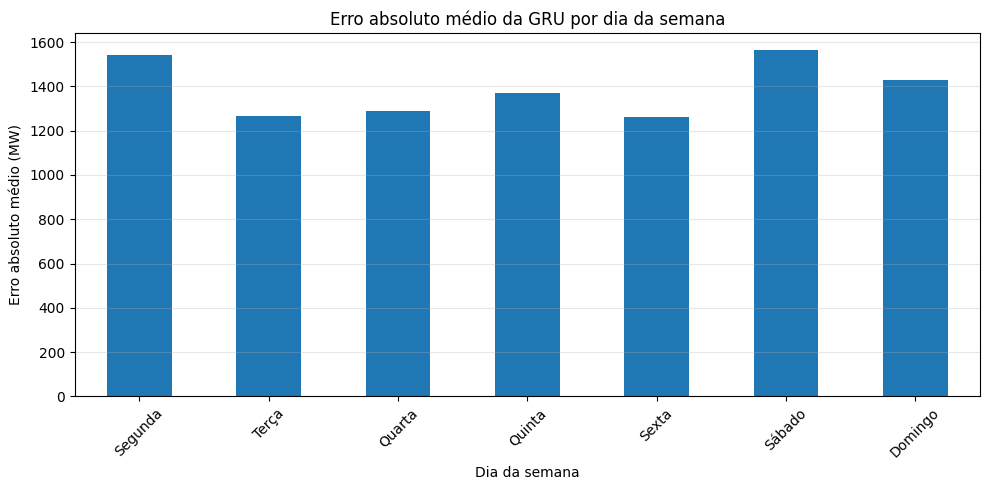

In [97]:
plt.figure(figsize=(10, 5))

erro_por_dia.plot(kind="bar")

plt.title("Erro absoluto médio da GRU por dia da semana")
plt.xlabel("Dia da semana")
plt.ylabel("Erro absoluto médio (MW)")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 14.5 Identificação dos maiores erros
Identificamos e ordenamos os maiores erros absolutos, permitindo uma análise específica das situações em que o modelo apresentou pior desempenho.

Observar esses casos ajuda a verificar se os maiores desvios estão associados a picos de demanda, mudanças bruscas no consumo ou períodos com comportamento diferente do padrão observado durante o treinamento.

In [98]:
maiores_erros = (
    resultados_gru_df
    .sort_values(
        "erro_absoluto",
        ascending=False
    )
    .head(20)
)

maiores_erros[
    [
        "Datetime",
        "consumo_real",
        "consumo_previsto",
        "erro",
        "erro_absoluto"
    ]
]

,Datetime,consumo_real,consumo_previsto,erro,erro_absoluto
11105,2017-05-20 17:00:00,26068.0,37218.660156,-11150.660156,11150.660156
11104,2017-05-20 16:00:00,26068.0,37107.687500,-11039.687500,11039.687500
14251,2017-09-28 19:00:00,34126.0,44951.550781,-10825.550781,10825.550781
11106,2017-05-20 18:00:00,26125.0,36810.023438,-10685.023438,10685.023438
21354,2018-07-21 18:00:00,31147.0,41695.523438,-10548.523438,10548.523438
2875,2016-06-11 19:00:00,41298.0,30891.328125,10406.671875,10406.671875
21353,2018-07-21 17:00:00,31259.0,41627.093750,-10368.093750,10368.093750
11103,2017-05-20 15:00:00,26322.0,36601.750000,-10279.750000,10279.750000
2874,2016-06-11 18:00:00,40998.0,30745.185547,10252.814453,10252.814453
2876,2016-06-11 20:00:00,40672.0,30603.882812,10068.117188,10068.117188


## 14.6 Análise durante picos de consumo
Para avaliar o desempenho da GRU em situações de alta demanda, consideramos como picos os valores de consumo pertencentes aos 10% maiores valores observados no conjunto avaliado.

Comparamos então o erro médio nesses períodos com o erro observado fora dos picos.

Essa comparação permite verificar se o modelo mantém sua precisão quando a demanda atinge níveis mais elevados.

In [99]:
limiar_pico = resultados_gru_df[
    "consumo_real"
].quantile(0.90)

resultados_gru_df["pico_consumo"] = (
    resultados_gru_df["consumo_real"]
    >= limiar_pico
)

erro_picos = resultados_gru_df[
    resultados_gru_df["pico_consumo"]
]["erro_absoluto"].mean()

erro_fora_picos = resultados_gru_df[
    ~resultados_gru_df["pico_consumo"]
]["erro_absoluto"].mean()

print(
    f"Limiar para pico de consumo: "
    f"{limiar_pico:.2f} MW"
)

print(
    f"Erro absoluto médio durante picos: "
    f"{erro_picos:.2f} MW"
)

print(
    f"Erro absoluto médio fora dos picos: "
    f"{erro_fora_picos:.2f} MW"
)

Limiar para pico de consumo: 40154.60 MW
Erro absoluto médio durante picos: 2709.77 MW
Erro absoluto médio fora dos picos: 1241.98 MW


## 14.7 Visualização dos erros durante picos
O gráfico abaixo apresenta os erros obtidos especificamente nestes períodos classificados como picos de consumo.

Valores positivos indicam subestimação da demanda, enquanto valores negativos representam superestimação.

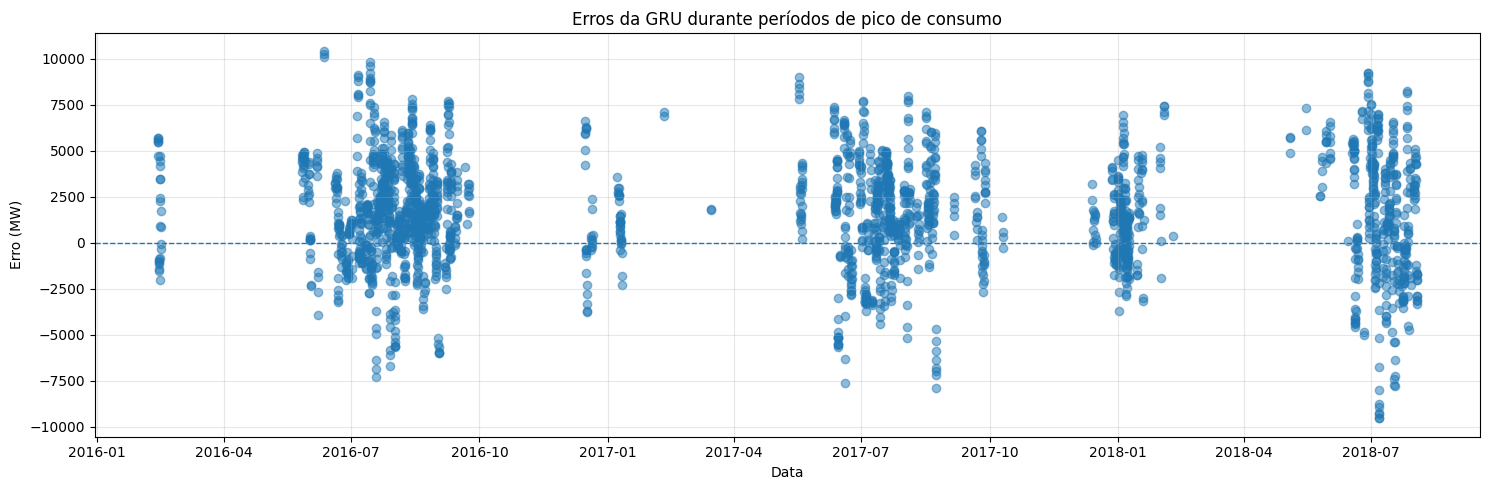

In [100]:
dados_picos = resultados_gru_df[
    resultados_gru_df["pico_consumo"]
]

plt.figure(figsize=(15, 5))

plt.scatter(
    dados_picos["Datetime"],
    dados_picos["erro"],
    alpha=0.5
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.title("Erros da GRU durante períodos de pico de consumo")
plt.xlabel("Data")
plt.ylabel("Erro (MW)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 14.8 Análise do erro por horizonte de previsão
Como o modelo prevê simultaneamente as próximas 24 horas, também podemos analisar o erro de acordo com a distância entre o instante atual e a hora prevista.

Essa análise permite verificar se a precisão do modelo diminui conforme aumenta a distância temporal da previsão.

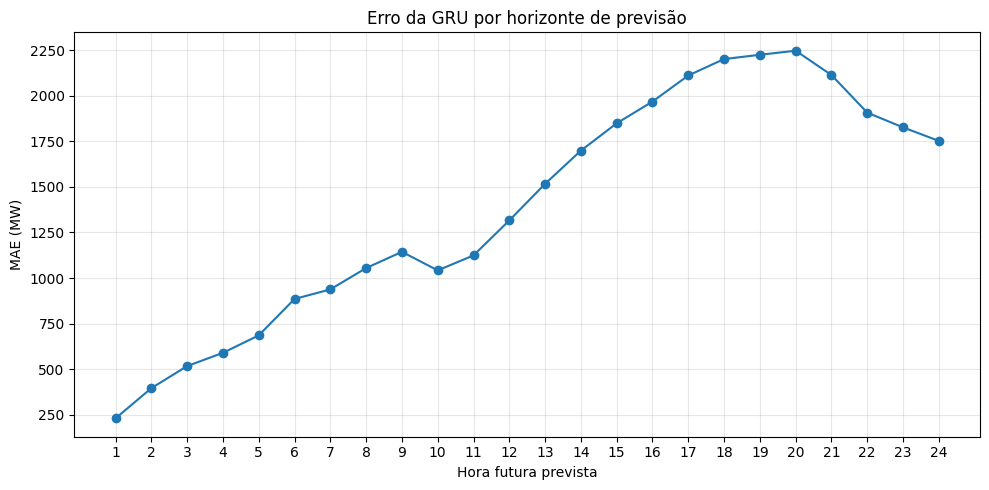

In [101]:
erro_por_horizonte = np.mean(
    np.abs(y_real_gru - y_pred_gru),
    axis=0
)

horas_futuras = np.arange(1, HORIZONTE + 1)

plt.figure(figsize=(10, 5))

plt.plot(
    horas_futuras,
    erro_por_horizonte,
    marker="o"
)

plt.title("Erro da GRU por horizonte de previsão")
plt.xlabel("Hora futura prevista")
plt.ylabel("MAE (MW)")
plt.xticks(horas_futuras)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Seção 15: Conclusões
Nesta etapa são reunidos os principais resultados obtidos durante o experimento.

A avaliação final deve considerar não apenas os valores globais de MAE e RMSE, mas também a comparação com o baseline e o comportamento da GRU em situações específicas, como picos de consumo, diferentes horários e dias da semana.

A comparação com o baseline permite verificar se a utilização de uma rede neural recorrente foi capaz de extrair padrões temporais que não são capturados pela estratégia simples de repetir o consumo do dia anterior.

A análise das subestimações e superestimações também é importante do ponto de vista operacional. Subestimar a demanda pode resultar em capacidade insuficiente de geração, enquanto superestimá-la pode provocar custos adicionais decorrentes do acionamento desnecessário de recursos.

Entre as principais limitações da solução está o fato de o modelo utilizar principalmente o histórico de consumo para realizar as previsões. A demanda de energia também pode ser influenciada por variáveis externas, como temperatura, condições climáticas, feriados e outros fatores sazonais que não são explicitamente considerados pelo modelo.

Além disso, os dados utilizados correspondem ao período de 2002 a 2018, de modo que mudanças mais recentes nos padrões de consumo não estão representadas no conjunto analisado.

Assim, os resultados obtidos permitem avaliar a capacidade da GRU de prever a demanda para as próximas 24 horas e identificar em quais condições o modelo apresenta melhor ou pior desempenho. A conclusão definitiva sobre a qualidade da solução deve considerar os valores finais das métricas e sua comparação com o baseline.

In [102]:
print("===== RESUMO FINAL =====")

print(f"\nGRU:")
print(f"MAE:  {mae_gru:.2f} MW")
print(f"RMSE: {rmse_gru:.2f} MW")

print(f"\nBaseline:")
print(f"MAE:  {mae_baseline:.2f} MW")
print(f"RMSE: {rmse_baseline:.2f} MW")

print(f"\nComparação:")
print(
    f"Variação do MAE em relação ao baseline: "
    f"{melhoria_mae:.2f}%"
)

print(
    f"Variação do RMSE em relação ao baseline: "
    f"{melhoria_rmse:.2f}%"
)

print(f"\nAnálise operacional:")
print(
    f"Subestimações: "
    f"{qtd_subestimacoes / total * 100:.2f}%"
)

print(
    f"Superestimações: "
    f"{qtd_superestimacoes / total * 100:.2f}%"
)

print(
    f"Erro médio em períodos de pico: "
    f"{erro_picos:.2f} MW"
)

print(
    f"Erro médio fora dos picos: "
    f"{erro_fora_picos:.2f} MW"
)

===== RESUMO FINAL =====

GRU:
MAE:  1388.78 MW
RMSE: 2011.09 MW

Baseline:
MAE:  2208.16 MW
RMSE: 3031.90 MW

Comparação:
Variação do MAE em relação ao baseline: 37.11%
Variação do RMSE em relação ao baseline: 33.67%

Análise operacional:
Subestimações: 42.33%
Superestimações: 57.67%
Erro médio em períodos de pico: 2709.77 MW
Erro médio fora dos picos: 1241.98 MW
